In [1]:
import numpy as np
import os
from PIL import Image
import torch
import torchvision.transforms as T
import torchvision.transforms.functional as TF
from matplotlib import pyplot as plt
from einops import rearrange

In [2]:
# ------------- User Settings -------------------
data_folder = "/scratch/gilbreth/lwickrem/data/HandpickedDegrads/gt"       # Your input image folder
output_folder = "/scratch/gilbreth/lwickrem/data/HandpickedDegrads/" # Where degraded images will be saved
IR_mode = "colorization"  # Select degradation mode
scale = 4                  # Used for super resolution
scale_h = 4
scale_w = 4
device = "cuda" if torch.cuda.is_available() else "cpu"
# -----------------------------------------------

In [3]:
# ---------- Degradation Operators -------------
#https://github.com/wyhuai/DDNM

def color2gray(x):
# Convert RGB image to grayscale by averaging the channels,but repeat it to maintain 3 channel structure.
    coef = 1/3
    gray = x[:, 0, :, :] * coef + x[:, 1, :, :] * coef + x[:, 2, :, :] * coef
    return gray.unsqueeze(1).repeat(1, 3, 1, 1)

    # # For input shape [N, H, W, 3]
    # coef = 1/3
    # # Average across the last dimension (the 3 color channels)
    # gray = x[..., 0] * coef + x[..., 1] * coef + x[..., 2] * coef  # shape: (N, H, W)

    # gray = gray.unsqueeze(-1)  # shape: (N, H, W, 1)
    # return gray.repeat(1, 1, 1, 3)  # shape: (N, H, W, 3)

def PatchUpsample(x, scale):
    n, c, h, w = x.shape
    x = x.view(n, c, h, 1, w, 1).expand(-1, -1, -1, scale, -1, scale)
    return x.contiguous().view(n, c, h * scale, w * scale)

def PatchUpsampleEmbeds(x, scale_h, scale_w):
    n, c, h, w = x.shape
    # Embedding dimensions change into [B, Cenc, Henc, Wenc]. So we need new scale_h and scale_w for embeddings.
    x = x.view(n, c, h, 1, w, 1).expand(-1, -1, -1, scale_h, -1, scale_w)
    return x.contiguous().view(n, c, h * scale_h, w * scale_w)

def gray2color(x):
    # Input shape: [N, 3, H, W] where all 3 channels are the same
    # First reduce to single channel
    x = x[:, 0, :, :]  # shape: [N, H, W]
    
    coef = 1/3
    # Reverse the averaging operation by scaling up
    base = coef**2 + coef**2 + coef**2  # sum of squared coefficients
    restored = x * coef / base  # scale back to plausible RGB value

    # Stack it back to 3 channels
    return torch.stack([restored, restored, restored], dim=1)  # shape: [N, 3, H, W]

    # x_single = x[..., 0]  # (N, H, W)
    # coef = 1/3
    # base = coef**2 + coef**2 + coef**2
    # restored = x_single * (coef / base)  # (N, H, W)

    # # Stack back to 3 channels along the last dim
    # return torch.stack([restored, restored, restored], dim=-1) # shape: [N, H, W, 3]
    
    

In [4]:
def set_operator(img_shape, IR_mode):
    if IR_mode == "colorization":
        _, _, h, w = img_shape
        return color2gray

    elif IR_mode == "inpainting":
        _, _, h, w = img_shape
        mask = torch.ones(img_shape, device=device)
        mask[:, :, h//4:h*3//4, w//4:w*3//4] = 0
        return lambda z: z * mask

    elif IR_mode == "super resolution":
        _, _, h, w = img_shape
        down = torch.nn.AdaptiveAvgPool2d((h // scale, w // scale))
        # #maintain input image size
        # up = torch.nn.Upsample(size=(h, w), mode="bilinear", align_corners=False)
        return lambda z: down(z)
    
    if IR_mode == "super resolution embeds":
        _, _, h, w = img_shape
        #  Embedding dimensions change into [B, Cenc, Henc, Wenc]. So we need new scale_h and scale_w for embeddings.
        down = torch.nn.AdaptiveAvgPool2d((h // scale_h, w // scale_w))
        return lambda z: down(z)

    elif IR_mode == "old photo restoration":
        _, _, h, w = img_shape
        mask = torch.ones(img_shape, device=device)
        mask[:, :, h//4:h*3//4, w//4:w*3//4] = 0
        A1 = lambda z: z * mask
        A2 = color2gray
        A3 = torch.nn.AdaptiveAvgPool2d((h // scale, w // scale))
        return lambda z: A3(A2(A1(z)))

    else:
        raise ValueError(f"Unknown IR_mode: {IR_mode}")

In [5]:
def set_pinv_operator(img_shape, IR_mode):
    _, _, h, w = img_shape
    if IR_mode == "colorization":
        return gray2color

    elif IR_mode == "inpainting":
        mask = torch.ones(img_shape, device=device)
        mask[:, :, h//4:h*3//4, w//4:w*3//4] = 0
        return lambda z: z * mask

    elif IR_mode == "super resolution":
        # The input to Ap is the downsampled image, so we upsample with PatchUpsample
        return lambda z: PatchUpsample(z, scale)
    
    elif IR_mode == "super resolution embeds":
        # The input to Ap is the downsampled image, so we upsample with PatchUpsample
        return lambda z: PatchUpsampleEmbeds(z, scale_h, scale_w)

    elif IR_mode == "old photo restoration":
        mask = torch.ones(img_shape, device=device)
        mask[:, :, h//4:h*3//4, w//4:w*3//4] = 0
        A1p = lambda z: z * mask
        A2p = gray2color
        A3p = lambda z: PatchUpsample(z, scale)
        return lambda z: A1p(A2p(A3p(z)))

    else:
        raise ValueError(f"Unknown IR_mode: {IR_mode}")
# -----------------------------------------------

In [6]:
def ddnm_simple(xt, y, z, t, lambda_t=0.1, IR_mode="super resolution"):
# Refer: https://arxiv.org/pdf/2212.00490
# https://github.com/wyhuai/DDNM

    # x0t = xt
    x0t = (xt - (t)*z)/ ((1-t) + 1e-10)

    A = set_operator(x0t.shape, IR_mode)
    Ap = set_pinv_operator(x0t.shape, IR_mode)
        
    # For debugging dimensions.
    y0_hat = A(x0t)
    yres = y - y0_hat
    xres = Ap(yres)
    x0t= x0t + lambda_t*xres

    # xt = x0t
    xt = (t)*z + (1-t)*x0t
    
    return xt


Debugging the ddnm simple algorithm

In [7]:
def to_img(t, idx=0):
    """
    Convert (N,C,H,W) tensor to numpy image (H,W,C) in [0,1] for plotting.
    """
    if isinstance(t, torch.Tensor):
        img = t[idx].detach().cpu().numpy() # (C,H,W)
    else:
        img = t[idx] # assume (C,H,W)

    img = img.transpose(1, 2, 0)  # (H,W,C)
    
    # Normalize to [0,1] just for display
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    return img

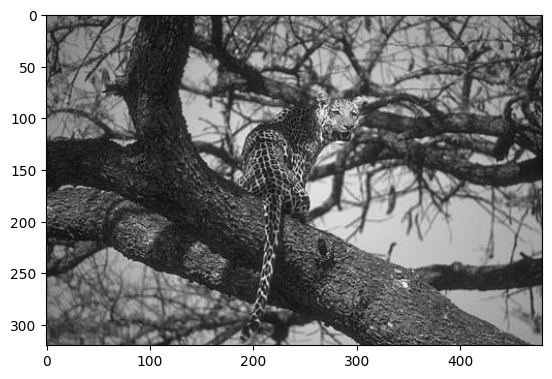

In [8]:
source_dir = "/scratch/gilbreth/lwickrem/data/HandpickedDegrads/colorization/134049.jpg"
init_image = np.array(Image.open(source_dir).convert('RGB'))
shape = init_image.shape

new_h = shape[0] if shape[0] % 16 == 0 else shape[0] - shape[0] % 16
new_w = shape[1] if shape[1] % 16 == 0 else shape[1] - shape[1] % 16

init_image = init_image[:new_h, :new_w, :]
plt.imshow(init_image)
# plt.axis('off')
plt.show()

In [9]:
y = torch.from_numpy(init_image).float().unsqueeze(0)
y = rearrange(y, 'b h w c-> b c h w') 
print(f"y shape: {y.shape}")

y shape: torch.Size([1, 3, 320, 480])


xt_hat shape: (320, 480, 3), z shape: (320, 480, 3)


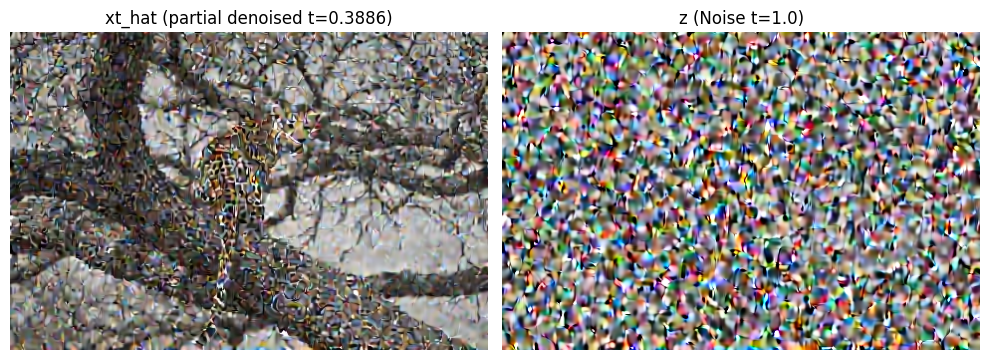

In [10]:
source_dir = "/scratch/gilbreth/lwickrem/RF_Inversion/RF-Solver-Edit/FLUX_Image_Edit/src"

t=0.3886
xt_hat = np.array(Image.open(source_dir+'/test_itr22_t=0.3886.png' ).convert('RGB'))
z = np.array(Image.open(source_dir+'/test_itr0_t=1.0000.png' ).convert('RGB'))
print(f"xt_hat shape: {xt_hat.shape}, z shape: {z.shape}")

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(xt_hat)
axes[0].set_title("xt_hat (partial denoised t=0.3886)")
axes[0].axis("off")

axes[1].imshow(z)
axes[1].set_title("z (Noise t=1.0)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

xt_hat = torch.from_numpy(xt_hat).float().unsqueeze(0)
xt_hat = rearrange(xt_hat, 'b h w c-> b c h w')

z = torch.from_numpy(z).float().unsqueeze(0)
z = rearrange(z, 'b h w c-> b c h w')

In [11]:
A = set_operator(y.shape, IR_mode)
Ap = set_pinv_operator(y.shape, IR_mode)  

y_hat = A(xt_hat)
print(f"y_hat shape: {y_hat.shape}")

y_hat shape: torch.Size([1, 3, 320, 480])


tensor(-197.6667) tensor(176.)
tensor(0.) tensor(255.)
tensor(-27.5130) tensor(274.1572)


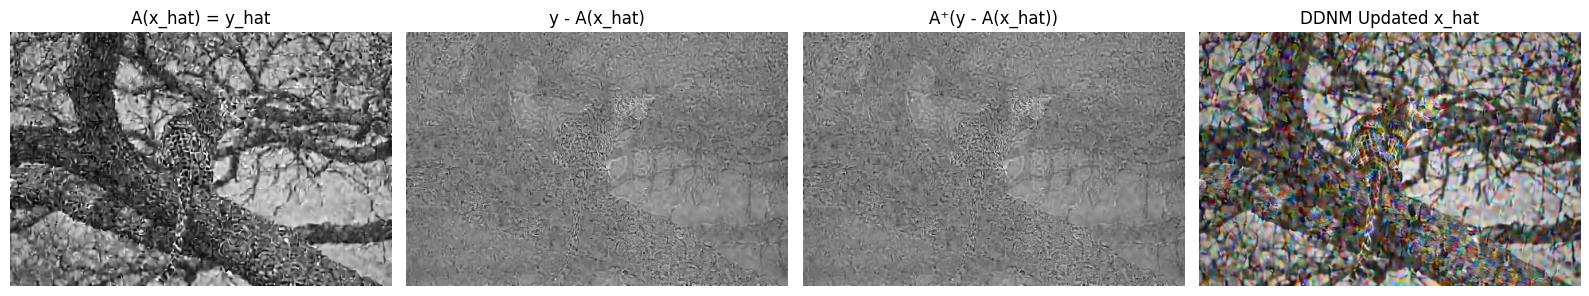

In [ ]:
A = set_operator(y.shape, IR_mode)
Ap = set_pinv_operator(y.shape, IR_mode)
lambda_t = 1  

# x0t = xt_hat
x0t = (xt_hat - (1-t)*z)/ (t + 1e-10)

y0_hat = A(xt_hat)           # forward
yres   = y - y0_hat         # residual in measurement space
xres   = Ap(yres)           # backprojected residual
# print(type(xres), xres.shape) # Tensor, torch.Size([1, 3, 256, 256])
print(xres.min(), xres.max())   # -214.3333 , 199.6667
print(xt_hat.min(), xt_hat.max()) #  0.0 , 255.0
DDNM_x0t    = xt_hat + lambda_t*xres

# DDNM_xthat = DDNM_x0t
DDNM_xthat = (t)*z + (1-t)*DDNM_x0t

print(DDNM_xthat.min(), DDNM_xthat.max()) #-58.6667, 303.3333
DDNM_xthat = torch.clamp(DDNM_xthat, 0, 255)


imgs = [to_img(y0_hat), to_img(yres), to_img(xres), to_img(DDNM_xthat)]
titles = ["A(x_hat) = y_hat", "y - A(x_hat)", "A⁺(y - A(x_hat))", "DDNM Updated x_hat"]

fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

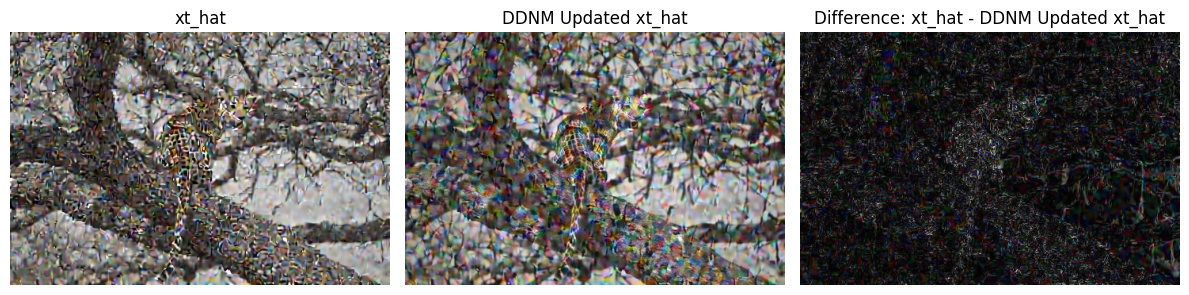

In [ ]:
im1 = to_img(xt_hat)
im2 = to_img(DDNM_xthat)

# Compute absolute difference, normalize to [0,1] for visualization
diff = np.abs(im1 - im2)
diff = diff / (diff.max() + 1e-8)

imgs = [im1, im2, diff]
titles = ["xt_hat", "DDNM Updated xt_hat", "Difference: xt_hat - DDNM Updated xt_hat"]

fig, axes = plt.subplots(1, 3, figsize=(12,4))
for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
im1 = to_img(xt_hat)
im2 = to_img(x0t)
im3 = to_img(DDNM_x0t)
im4 = to_img(DDNM_xthat)

# Compute absolute difference, normalize to [0,1] for visualization
diff = np.abs(im1 - im2)
diff = diff / (diff.max() + 1e-8)

imgs = [im1, im2, im3, im4]
titles = ["xt_hat", "linear interpolated x0t", "DDNM Updated x0t", "DDNM Updated xt_hat"]

fig, axes = plt.subplots(1, 4, figsize=(12,4))
for ax, im, title in zip(axes, imgs, titles):
    ax.imshow(im)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()